In [3]:
import numpy as np
import pandas as pd
from pycaret.regression import *
import matplotlib.pyplot as plt 
import seaborn as sns


In [5]:
# load dataset
data = sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Preprocessing: Encoding categorical variables
# This is another way of encoding
data['sex'] = data['sex'].astype('category').cat.codes
data['smoker'] = data['smoker'].astype('category').cat.codes
data['day'] = data['day'].astype('category').cat.codes
data['time'] = data['time'].astype('category').cat.codes



In [7]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,1,3,1,2
1,10.34,1.66,0,1,3,1,3
2,21.01,3.50,0,1,3,1,3
3,23.68,3.31,0,1,3,1,2
4,24.59,3.61,1,1,3,1,4


In [9]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [10]:
# Inatializing the pyCaret regression setup without experimental logging
regression_setup = setup(
    data=train,
    target='tip',
    session_id=123,
    normalize=True,
    polynomial_features=True,
    remove_multicollinearity=True,
    log_experiment=False,
    experiment_name='tips_regression',
    verbose=False
)

In [12]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [11]:
# Compare best model 
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.7737,1.0485,1.0003,0.4007,0.2402,0.2948,0.1200
ridge,Ridge Regression,0.7765,1.0340,0.9920,0.3991,0.2429,0.2957,0.1700
lr,Linear Regression,0.7846,1.0503,0.9997,0.3874,0.2467,0.2998,3.8840
omp,Orthogonal Matching Pursuit,0.8021,1.1253,1.0340,0.3784,0.2461,0.3077,0.1170
huber,Huber Regressor,0.7799,1.0790,1.0048,0.3777,0.2442,0.2883,0.1480
lightgbm,Light Gradient Boosting Machine,0.7921,1.1320,1.0301,0.3627,0.2453,0.2998,0.1610
knn,K Neighbors Regressor,0.8152,1.1485,1.0585,0.3340,0.2599,0.3118,0.1450
rf,Random Forest Regressor,0.8248,1.2082,1.0746,0.3204,0.2599,0.3181,0.4450
catboost,CatBoost Regressor,0.8243,1.2055,1.0750,0.3158,0.2614,0.3161,3.1590
ada,AdaBoost Regressor,0.8338,1.1792,1.0723,0.3069,0.2569,0.3289,0.2880


In [13]:
print(best_model)

BayesianRidge()


In [15]:
# Tune model for best perfomance
tuned_model =  tune_model(best_model, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8682,1.1779,1.0853,0.1580,0.2753,0.3593
1,1.0865,1.9881,1.4100,0.1977,0.2911,0.2889
2,0.8878,1.0873,1.0428,0.2033,0.3102,0.4623
3,0.8857,1.3700,1.1705,0.0863,0.2691,0.3100
4,0.8113,1.0636,1.0313,0.2415,0.2792,0.3753
5,0.6730,0.8827,0.9395,0.5933,0.2017,0.2391
6,0.7520,0.9959,0.9980,0.4096,0.2215,0.2365
7,0.5685,0.5572,0.7465,0.6049,0.2159,0.2792
8,0.7221,0.9432,0.9712,0.7196,0.1850,0.1890


Fitting 10 folds for each of 10 candidates, totalling 100 fits


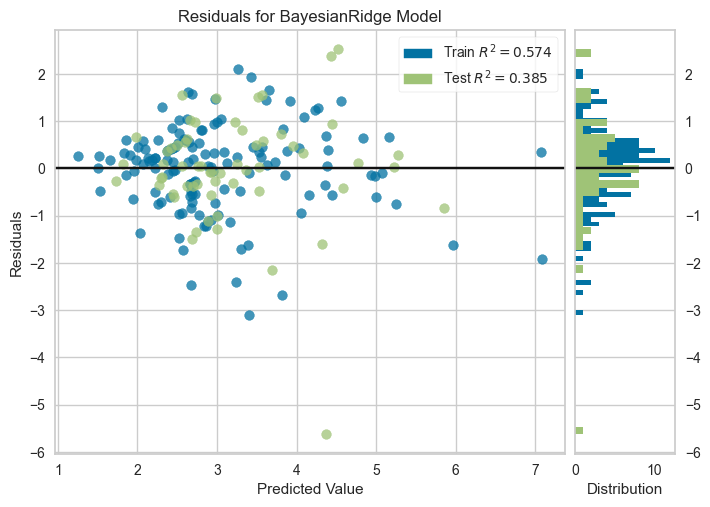

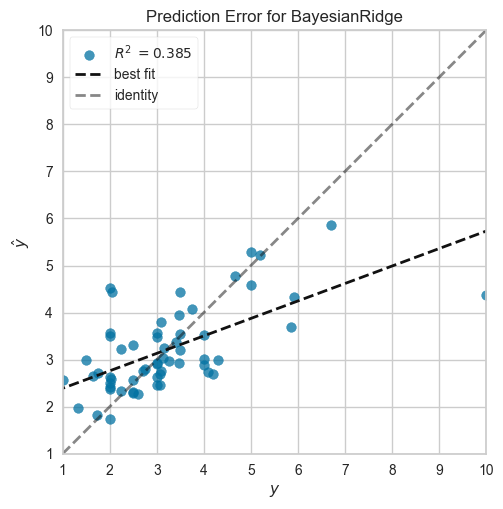

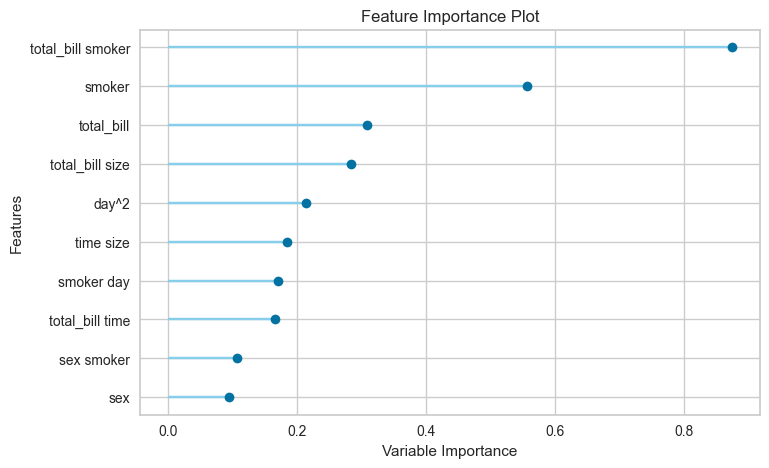

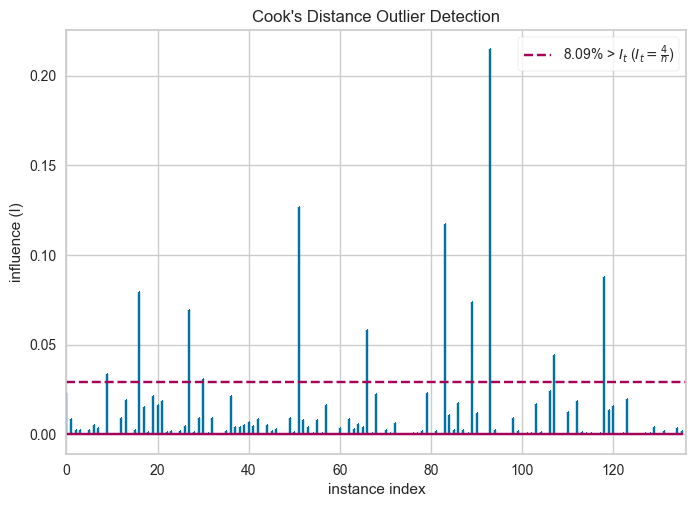

In [19]:
# Evaluate the tuned model
plot_model(tuned_model, plot='residuals')
plot_model(tuned_model, plot='error')
plot_model(tuned_model, plot='feature')
plot_model(tuned_model, plot='cooks')





#### Assigments what is cooks distance

In [ ]:
# Evaluate model for better understanding
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [21]:
# final model for deployment
final_model = finalize_model(tuned_model)


In [22]:
# Prediction on test dataset
prediction = predict_model(final_model, data=test)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,0.7400,0.8974,0.9473,0.2821,0.2243,0.3031


In [23]:
# Evaluate perfomance
from sklearn.metrics import r2_score, mean_squared_error

In [24]:
# Extract true and predicted values
true_values = test['tip']


print(prediction.columns)

predicted_values = prediction['prediction_label']

Index(['total_bill', 'sex', 'smoker', 'day', 'time', 'size', 'tip',
       'prediction_label'],
      dtype='object')


In [25]:
mse = mean_squared_error(true_values, predicted_values)
r2 = r2_score(true_values, predicted_values)

In [26]:
print(f"Mean Squared Error: {mse}")
print(f"Mean Squared Error: {r2}")


Mean Squared Error: 0.8973686509164922
Mean Squared Error: 0.2820886220230562


In [27]:
save_model(final_model, './saved_models/pycaret_best_tips_regression')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['total_bill', 'sex', 'smoker',
                                              'day', 'time', 'size'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('polynomial_features',
                  TransformerWrapper(transformer=PolynomialFeatures(include_bias=False))),
                 ('remove_multicollinearity',
                  TransformerWrapper(exclude=[],
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('normalize', TransformerWrapper(transformer=StandardScaler())),
                 ('actual_estimator',
                  BayesianRidge(alpha_1=0.01, alpha_2=1e-07, lambda_1=0.05,
          

In [29]:
# Load model and predict
new_predictions = predict_model(loaded_model, data=test)

NameError: name 'loaded_model' is not defined

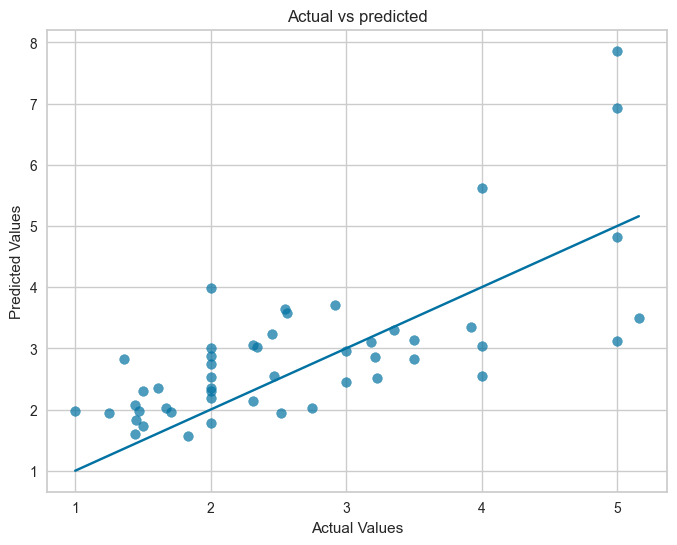

In [30]:
# Additional Analysis
plt.figure(figsize=(8, 6))
plt.scatter(true_values, predicted_values, alpha=0.7)
plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()])
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs predicted')
plt.show()